In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


In [3]:

df = pd.read_csv('../data/Clean_Dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

df.head(3)

Shape: (300153, 12)

Dtypes:
Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [4]:

df.drop(columns=['Unnamed: 0', 'flight'], inplace=True)


print(f"Columns remaining: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

Columns remaining: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']
Shape: (300153, 10)


In [6]:

cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n[{col}]  unique={df[col].nunique()}")
    


[airline]  unique=6

[source_city]  unique=6

[departure_time]  unique=6

[stops]  unique=3

[arrival_time]  unique=6

[destination_city]  unique=6

[class]  unique=2


In [7]:
for col in cat_cols:
    print(f"\n[{col}]  unique={df[col].value_counts()}")


[airline]  unique=airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

[source_city]  unique=source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

[departure_time]  unique=departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

[stops]  unique=stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

[arrival_time]  unique=arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

[destination_city]  unique=destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad 

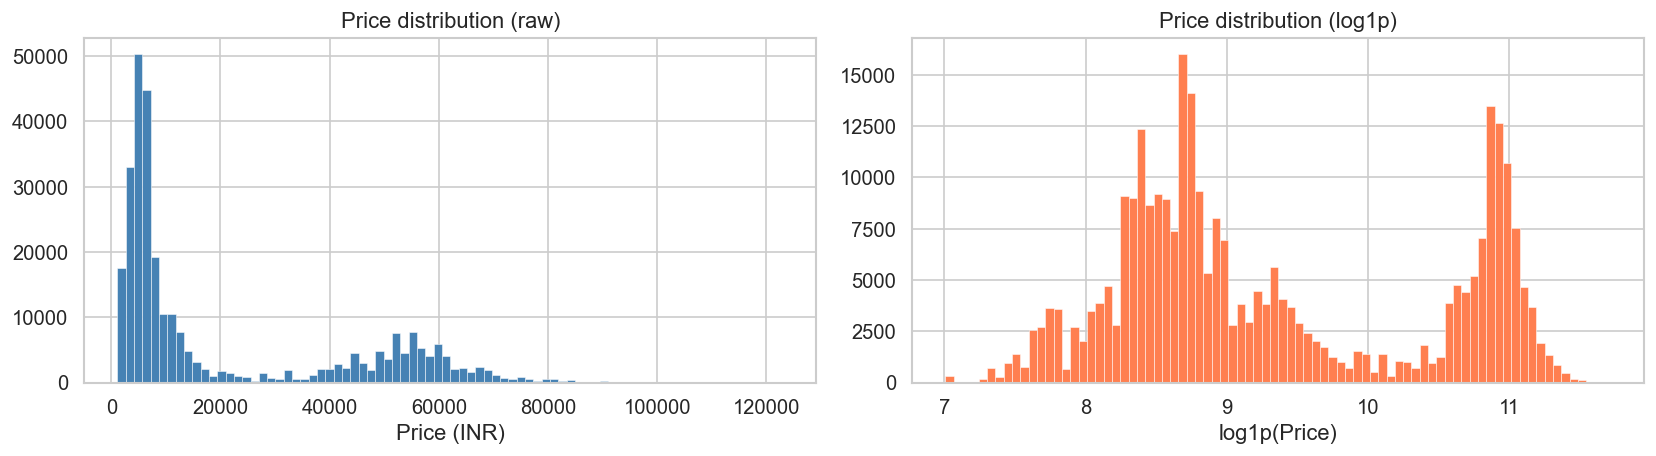


Skewness raw:    1.061
Skewness log1p: 0.405


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price distribution (raw)')
axes[0].set_xlabel('Price (INR)')

axes[1].hist(np.log1p(df['price']), bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Price distribution (log1p)')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nSkewness raw:    {df['price'].skew():.3f}")
print(f"Skewness log1p: {np.log1p(df['price']).skew():.3f}")


C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\2464187153.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='airline', y='price', order=order, palette='Set2')


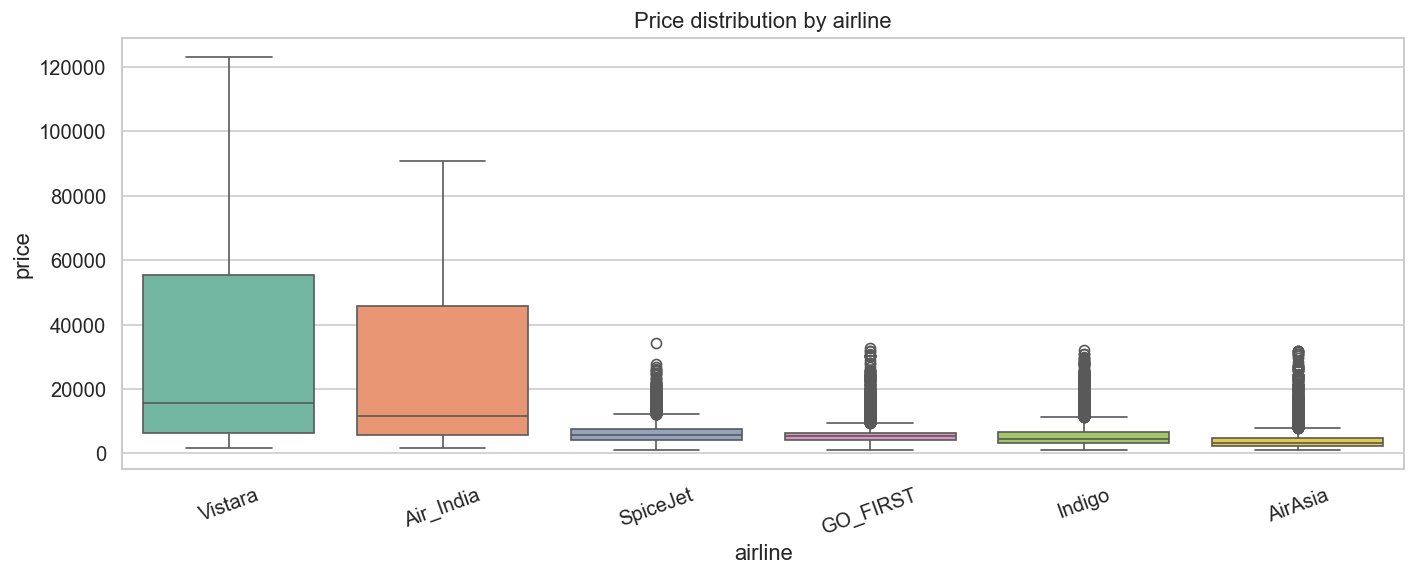

In [10]:

order = df.groupby('airline')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='airline', y='price', order=order, palette='Set2')
plt.xticks(rotation=20)
plt.title('Price distribution by airline')
plt.tight_layout()
plt.savefig('price_by_airline.png', bbox_inches='tight')
plt.show()

C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\2673294750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='price', ax=axes[0], palette='pastel')
C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\2673294750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stops', y='price', ax=axes[1], palette='pastel',


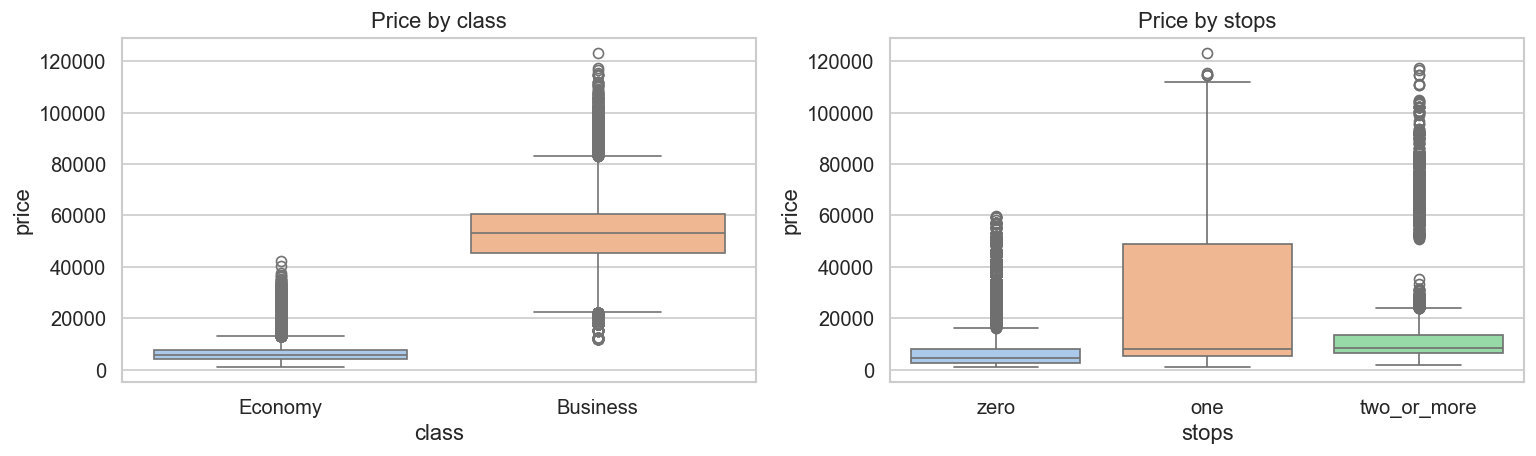

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='class', y='price', ax=axes[0], palette='pastel')
axes[0].set_title('Price by class')

sns.boxplot(data=df, x='stops', y='price', ax=axes[1], palette='pastel',
            order=['zero', 'one', 'two_or_more'])
axes[1].set_title('Price by stops')

plt.tight_layout()
plt.savefig('../reports/price_class_stops.png', bbox_inches='tight')
plt.show()

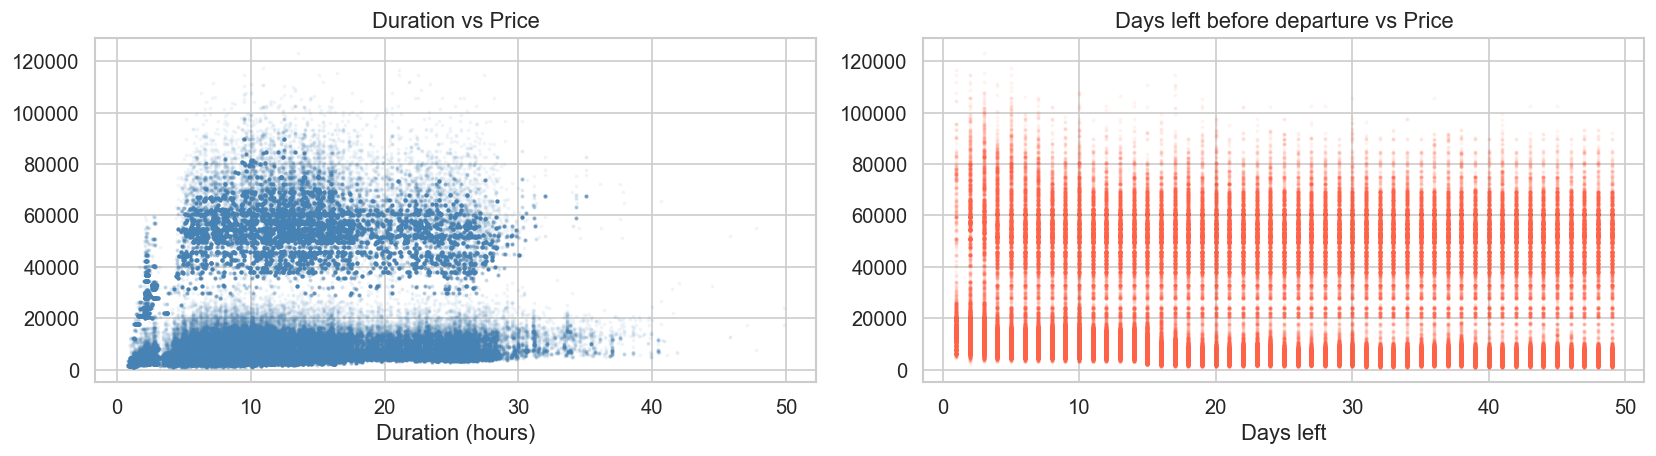

Correlation duration–price:   0.204
Correlation days_left–price:  -0.092


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['duration'], df['price'], alpha=0.05, s=2, color='steelblue')
axes[0].set_title('Duration vs Price')
axes[0].set_xlabel('Duration (hours)')

axes[1].scatter(df['days_left'], df['price'], alpha=0.05, s=2, color='tomato')
axes[1].set_title('Days left before departure vs Price')
axes[1].set_xlabel('Days left')

plt.tight_layout()
plt.savefig('../reports/duration_daysleft_vs_price.png', bbox_inches='tight')
plt.show()

print(f"Correlation duration–price:   {df['duration'].corr(df['price']):.3f}")
print(f"Correlation days_left–price:  {df['days_left'].corr(df['price']):.3f}")

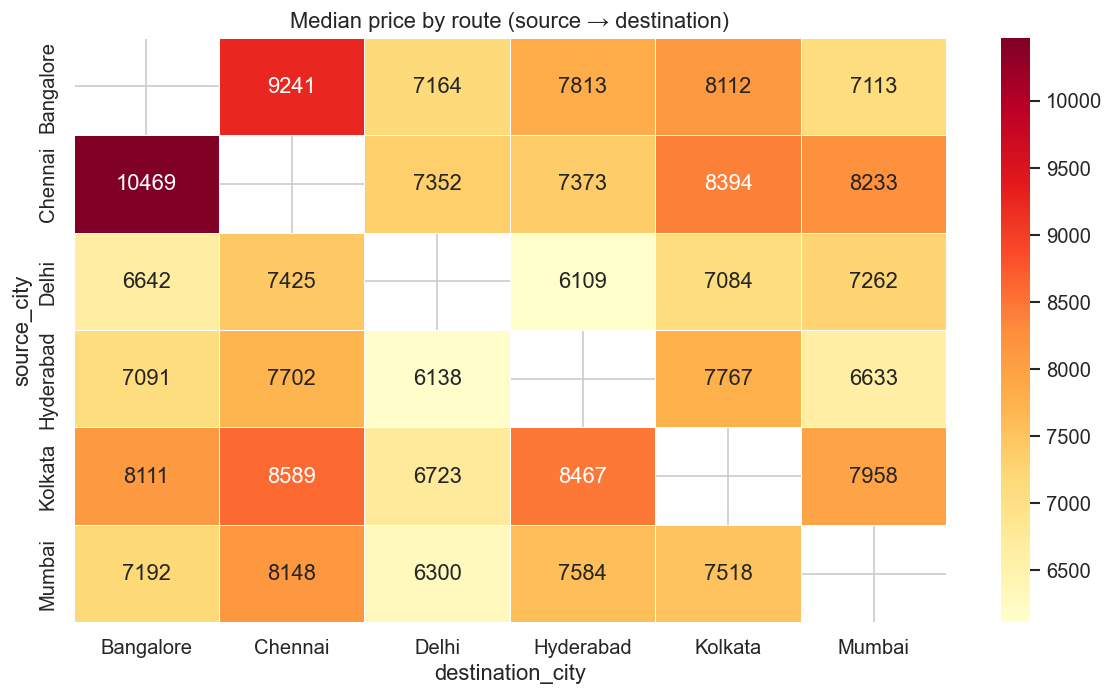

In [14]:

route_pivot = df.groupby(['source_city', 'destination_city'])['price'].median().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(route_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.4)
plt.title('Median price by route (source → destination)')
plt.tight_layout()
plt.savefig('../reports/route_heatmap.png', bbox_inches='tight')
plt.show()

C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\3634625646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='departure_time', y='price', order=dep_order,
C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\3634625646.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='arrival_time', y='price', order=arr_order,


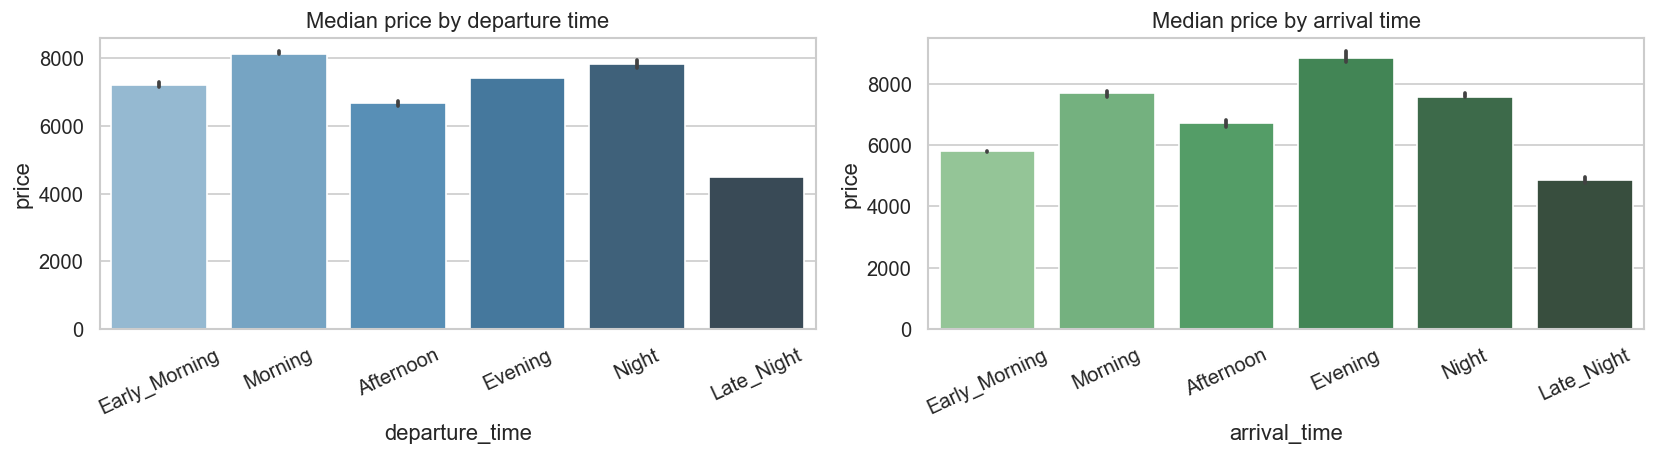

In [15]:

time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dep_order = [t for t in time_order if t in df['departure_time'].unique()]
arr_order = [t for t in time_order if t in df['arrival_time'].unique()]

sns.barplot(data=df, x='departure_time', y='price', order=dep_order,
            estimator=np.median, ax=axes[0], palette='Blues_d')
axes[0].set_title('Median price by departure time')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=df, x='arrival_time', y='price', order=arr_order,
            estimator=np.median, ax=axes[1], palette='Greens_d')
axes[1].set_title('Median price by arrival time')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../reports/time_vs_price.png', bbox_inches='tight')
plt.show()

In [16]:

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Price range:    {df['price'].min():,} – {df['price'].max():,}")
print(f"IQR bounds:     {lower:,.0f} – {upper:,.0f}")
print(f"Outlier count:  {len(outliers):,}  ({100*len(outliers)/len(df):.1f}%)")
print(f"\nOutlier breakdown by class:")
print(outliers['class'].value_counts())

Price range:    1,105 – 123,071
IQR bounds:     -51,824 – 99,128
Outlier count:  123  (0.0%)

Outlier breakdown by class:
class
Business    123
Name: count, dtype: int64


In [17]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [18]:
stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops_num'] = df['stops'].map(stops_map)


time_rank = {
    'Early_Morning': 0,
    'Morning':       1,
    'Afternoon':     2,
    'Evening':       3,
    'Night':         4,
    'Late_Night':    5
}
df['dep_time_num'] = df['departure_time'].map(time_rank)
df['arr_time_num'] = df['arrival_time'].map(time_rank)


df['is_business'] = (df['class'] == 'Business').astype(int)


df['urgency_num'] = pd.cut(
    df['days_left'],
    bins=[0, 7, 21, 49, 500],
    labels=[3, 2, 1, 0]   # higher = more urgent
).astype(int)

# 
df['duration_sq'] = df['duration'] ** 2


new_feats = ['stops_num', 'dep_time_num', 'arr_time_num',
             'is_business', 'urgency_num', 'duration_sq']

print("=== New features (all known at booking time) ===")
print(df[new_feats].head(4))
print(f"\nNull check:\n{df[new_feats].isnull().sum()}")

=== New features (all known at booking time) ===
   stops_num  dep_time_num  arr_time_num  is_business  urgency_num  \
0          0             3             4            0            3   
1          0             0             1            0            3   
2          0             0             0            0            3   
3          0             1             2            0            3   

   duration_sq  
0         4.71  
1         5.43  
2         4.71  
3         5.06  

Null check:
stops_num       0
dep_time_num    0
arr_time_num    0
is_business     0
urgency_num     0
duration_sq     0
dtype: int64


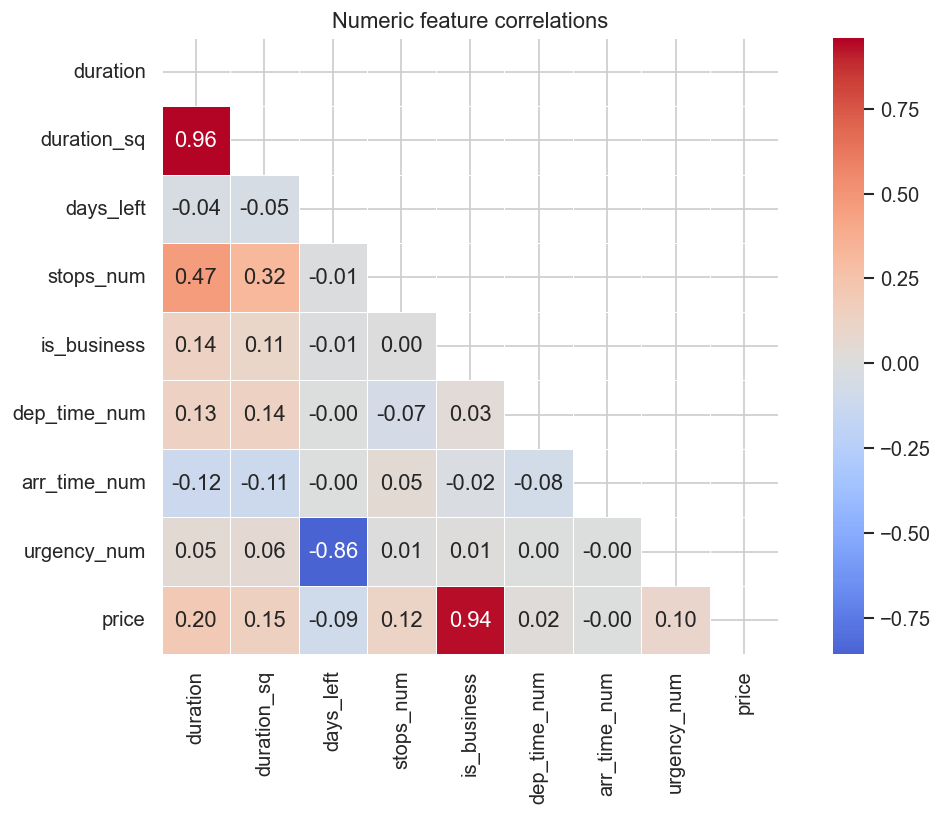

In [19]:

num_cols = [
    'duration', 'duration_sq', 'days_left', 'stops_num',
    'is_business', 'dep_time_num', 'arr_time_num',
    'urgency_num', 'price'
]

corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4, square=True)
plt.title('Numeric feature correlations')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', bbox_inches='tight')
plt.show()

C:\Users\kunan\AppData\Local\Temp\ipykernel_7504\2788646023.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=log_price,


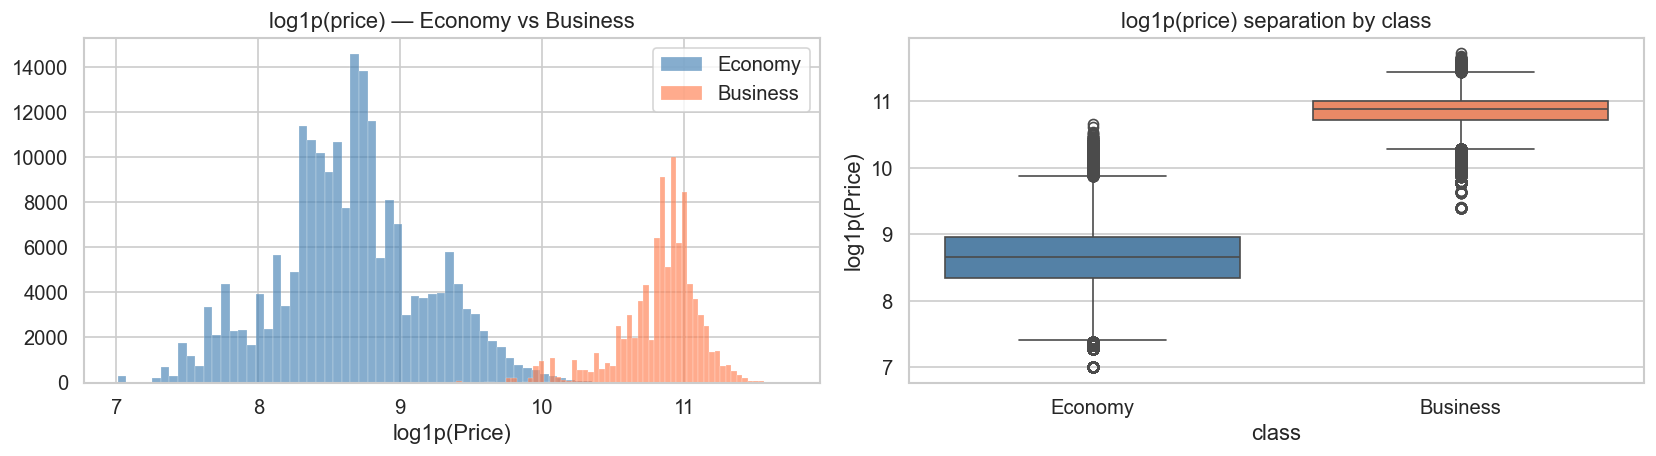

Economy  mean log_price: 8.651  ≈ ₹5,713
Business mean log_price: 10.834  ≈ ₹50,713
Log separation:          2.183 units


In [ ]:

log_price = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cls, color in [('Economy', 'steelblue'), ('Business', 'coral')]:
    mask = df['class'] == cls
    axes[0].hist(log_price[mask], bins=60, alpha=0.65,
                 color=color, label=cls, edgecolor='white', linewidth=0.2)

axes[0].set_title('log1p(price) — Economy vs Business')
axes[0].set_xlabel('log1p(Price)')
axes[0].legend()

sns.boxplot(data=df, x='class', y=log_price,
            palette={'Economy': 'steelblue', 'Business': 'coral'}, ax=axes[1])
axes[1].set_title('log1p(price) separation by class')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout()
plt.savefig('../reports/bimodal_class_separation.png', bbox_inches='tight')
plt.show()

eco_mean = log_price[df['class'] == 'Economy'].mean()
biz_mean = log_price[df['class'] == 'Business'].mean()
print(f"Economy  mean log_price: {eco_mean:.3f}  ≈ ₹{np.expm1(eco_mean):,.0f}")
print(f"Business mean log_price: {biz_mean:.3f}  ≈ ₹{np.expm1(biz_mean):,.0f}")
print(f"Log separation:          {biz_mean - eco_mean:.3f} units")

In [22]:
df.to_csv('../data/cleaned_out.csv',index=False)